In [1]:
# =========================================
# Cell 1: Import thư viện
# =========================================
import os
import glob
import time
import json
import joblib
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

print("Đã nạp xong các thư viện.")


Đã nạp xong các thư viện.


In [2]:
# =========================================
# Cell 2: Đọc và gộp dữ liệu từ nhiều CSV 
# =========================================
import glob
import pandas as pd
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))

if not csv_files:
    DATA_DIR = Path.cwd() / "data"
    csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
    
if not csv_files:
    raise FileNotFoundError(f"Không tìm thấy file CSV nào. Đã thử tìm tại: {DATA_DIR}")

print(f"Tìm thấy {len(csv_files)} file CSV tại: {DATA_DIR}")
print("Đang gộp dữ liệu...")

df_list = []
for file in csv_files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("Kích thước dữ liệu ban đầu:", df.shape)
df.head()

Tìm thấy 8 file CSV tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\data
Đang gộp dữ liệu...
Kích thước dữ liệu ban đầu: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# =========================================
# Cell 3: Làm sạch dữ liệu và Tối ưu bộ nhớ
# =========================================
print("Kích thước dữ liệu ban đầu:", df.shape)

df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)

before_dup = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Đã xóa {before_dup - df.shape[0]} dòng trùng lặp.")

numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_var_cols = df[numeric_cols].var(numeric_only=True)
zero_var_cols = zero_var_cols[zero_var_cols == 0].index.tolist()

if zero_var_cols:
    df.drop(columns=zero_var_cols, inplace=True)
    print(f"Đã xóa {len(zero_var_cols)} cột có phương sai bằng 0.")

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print("Kích thước dữ liệu sau khi làm sạch và tối ưu:", df.shape)


Kích thước dữ liệu ban đầu: (2830743, 79)
Đã xóa 308381 dòng trùng lặp.
Đã xóa 8 cột có phương sai bằng 0.
Kích thước dữ liệu sau khi làm sạch và tối ưu: (2522362, 71)


In [4]:
# =========================================
# Cell 4: Chọn 18 đặc trưng cốt lõi & Xử lý Nhãn cho LR
# =========================================
rename_map = {
    'Destination Port': 'Protocol', 'Total Fwd Packets': 'Tot Fwd Pkts',
    'Total Backward Packets': 'Tot Bwd Pkts', 'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
    'Total Length of Bwd Packets': 'TotLen Bwd Pkts', 'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
    'Bwd Packet Length Mean': 'Bwd Pkt Len Mean', 'Flow Bytes/s': 'Flow Byts/s',
    'Flow Packets/s': 'Flow Pkts/s', 'Packet Length Mean': 'Pkt Len Mean',
    'Packet Length Std': 'Pkt Len Std', 'SYN Flag Count': 'SYN Flag Cnt',
    'ACK Flag Count': 'ACK Flag Cnt', 'FIN Flag Count': 'FIN Flag Cnt',
    'RST Flag Count': 'RST Flag Cnt', 'PSH Flag Count': 'PSH Flag Cnt',
    'URG Flag Count': 'URG Flag Cnt'
}

df.rename(columns=rename_map, inplace=True)
df.columns = df.columns.str.strip()

selected_features = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'URG Flag Cnt'
]

if 'Label' not in df.columns:
    match_label = [c for c in df.columns if 'label' in c.lower()]
    if match_label: df.rename(columns={match_label[0]: 'Label'}, inplace=True)

df['Label'] = df['Label'].apply(lambda x: 'Web Attack' if 'Web Attack' in str(x) else x)

label_counts = df['Label'].value_counts()
valid_labels = label_counts[label_counts >= 50].index
df = df[df['Label'].isin(valid_labels)]

print("\nSố lượng nhãn sau khi gộp và lọc (Chuẩn bị cho LR):\n", df['Label'].value_counts())

X = df[selected_features].copy()
y = df['Label'].copy()

print("-" * 30)
print("Đã thiết lập thành công 18 features chuẩn!")
print("X:", X.shape)
print("y:", y.shape)


Số lượng nhãn sau khi gộp và lọc (Chuẩn bị cho LR):
 Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Web Attack             2143
Bot                    1953
Name: count, dtype: int64
------------------------------
Đã thiết lập thành công 18 features chuẩn!
X: (2522315, 18)
y: (2522315,)


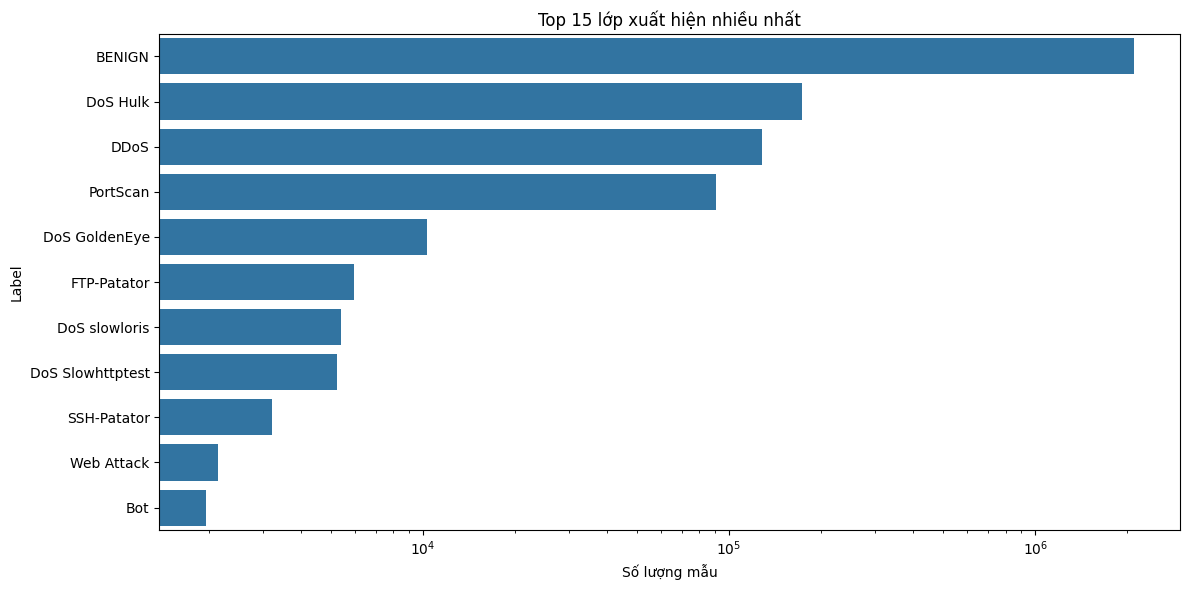

In [5]:
# =========================================
# Cell 5: EDA - Phân phối nhãn
# =========================================
plt.figure(figsize=(12, 6))
top_labels = y.value_counts().head(15)
sns.barplot(x=top_labels.values, y=top_labels.index)
plt.title("Top 15 lớp xuất hiện nhiều nhất")
plt.xlabel("Số lượng mẫu")
plt.ylabel("Label")
plt.xscale('log')
plt.tight_layout()
plt.show()


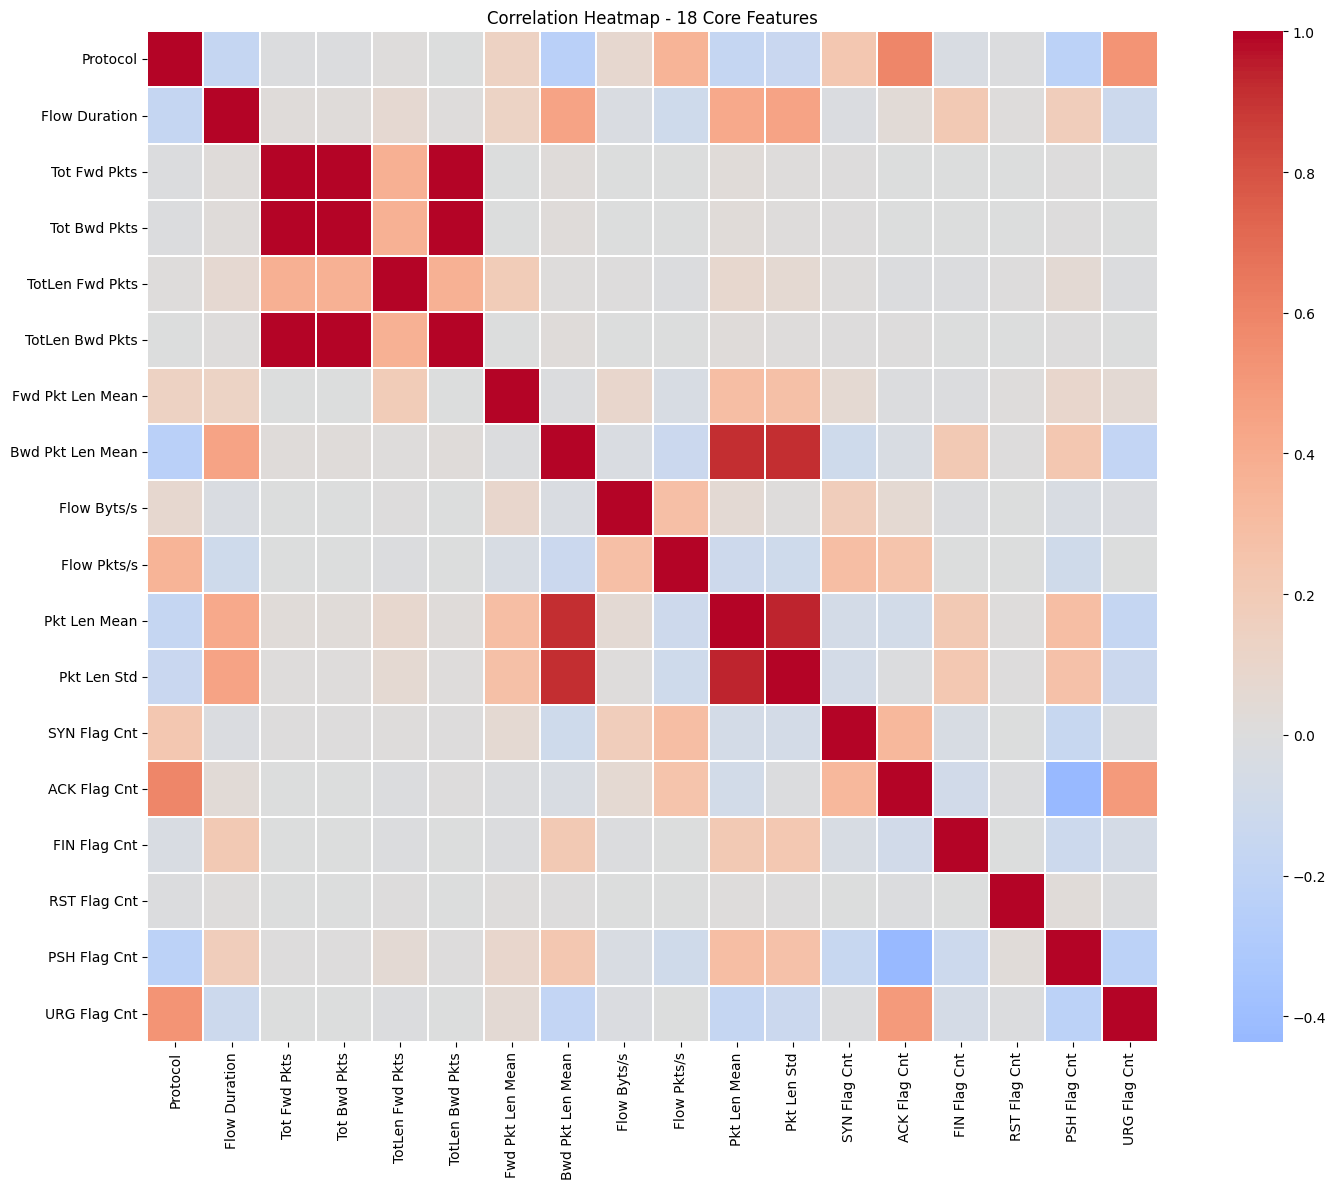

In [6]:
# =========================================
# Cell 6: EDA - Correlation Heatmap
# =========================================
plt.figure(figsize=(16, 12))
corr = df[selected_features].corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.2
)
plt.title('Correlation Heatmap - 18 Core Features')
plt.tight_layout()
plt.show()


In [7]:
# =========================================
# Cell 7: Mã hóa nhãn + chia train/test
# =========================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (2017852, 18) (2017852,)
Test : (504463, 18) (504463,)


In [8]:
# =========================================
# Cell 8: Pipeline chuẩn cho Logistic Regression
# =========================================
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import time

train_counts = Counter(y_train)
majority_class = max(train_counts, key=train_counts.get)
majority_count = train_counts[majority_class]

print("Phân phối lớp trước cân bằng (train):")
for cls, cnt in sorted(train_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  class={cls:>2} | count={cnt}")

under_target = min(majority_count, 150000) 
under_strategy = {majority_class: under_target}

pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('under', RandomUnderSampler(
        sampling_strategy=under_strategy, 
        random_state=42
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        max_iter=3000,        
        C=1.0,                  
        solver='saga',          
        n_jobs=-1,
        random_state=42
    ))
])

start_time = time.time()
print("\nĐang huấn luyện mô hình Logistic Regression...")
pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"Huấn luyện xong trong {train_time:.2f} giây.")

Phân phối lớp trước cân bằng (train):
  class= 0 | count=1677187
  class= 4 | count=138279
  class= 2 | count=102413
  class= 8 | count=72655
  class= 3 | count=8229
  class= 7 | count=4746
  class= 6 | count=4308
  class= 5 | count=4183
  class= 9 | count=2575
  class=10 | count=1714

Đang huấn luyện mô hình Logistic Regression...
Huấn luyện xong trong 1689.49 giây.


In [9]:
# =========================================
# Cell 9: Đánh giá mô hình
# =========================================
from sklearn.metrics import balanced_accuracy_score
from IPython.display import display

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"Accuracy         : {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"F1-macro         : {f1_macro:.4f}")
print(f"F1-weighted      : {f1_weighted:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

report_dict = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).T

class_rows = [cls for cls in le.classes_ if cls in report_df.index]
class_table = report_df.loc[class_rows, ['precision', 'recall', 'f1-score', 'support']].sort_values('recall')

print("\n=== CÁC LỚP CÓ RECALL THẤP NHẤT ===")
display(class_table.head(8).round(3))

print("\n=== MACRO / WEIGHTED AVG ===")
display(report_df.loc[['macro avg', 'weighted avg'], ['precision', 'recall', 'f1-score', 'support']].round(3))

=== KẾT QUẢ ĐÁNH GIÁ ===
Accuracy         : 0.7042
Balanced Accuracy: 0.8614
F1-macro         : 0.3885
F1-weighted      : 0.7865

=== CLASSIFICATION REPORT ===
                  precision    recall  f1-score   support

          BENIGN       1.00      0.65      0.79    419297
             Bot       0.01      0.75      0.01       390
            DDoS       0.56      0.99      0.72     25603
   DoS GoldenEye       0.17      0.91      0.29      2057
        DoS Hulk       0.89      0.94      0.91     34570
DoS Slowhttptest       0.04      0.83      0.08      1045
   DoS slowloris       0.22      0.57      0.32      1077
     FTP-Patator       0.16      0.99      0.27      1187
        PortScan       0.65      0.98      0.78     18164
     SSH-Patator       0.03      0.95      0.06       644
      Web Attack       0.02      0.91      0.03       429

        accuracy                           0.70    504463
       macro avg       0.34      0.86      0.39    504463
    weighted avg       0.9

,precision,recall,f1-score,support
DoS slowloris,0.218,0.571,0.316,1077.0
BENIGN,0.999,0.653,0.790,419297.0
Bot,0.007,0.749,0.014,390.0
DoS Slowhttptest,0.044,0.834,0.084,1045.0
DoS GoldenEye,0.172,0.909,0.289,2057.0
Web Attack,0.018,0.911,0.035,429.0
DoS Hulk,0.890,0.939,0.914,34570.0
SSH-Patator,0.033,0.949,0.064,644.0



=== MACRO / WEIGHTED AVG ===


,precision,recall,f1-score,support
macro avg,0.341,0.861,0.388,504463.0
weighted avg,0.945,0.704,0.786,504463.0


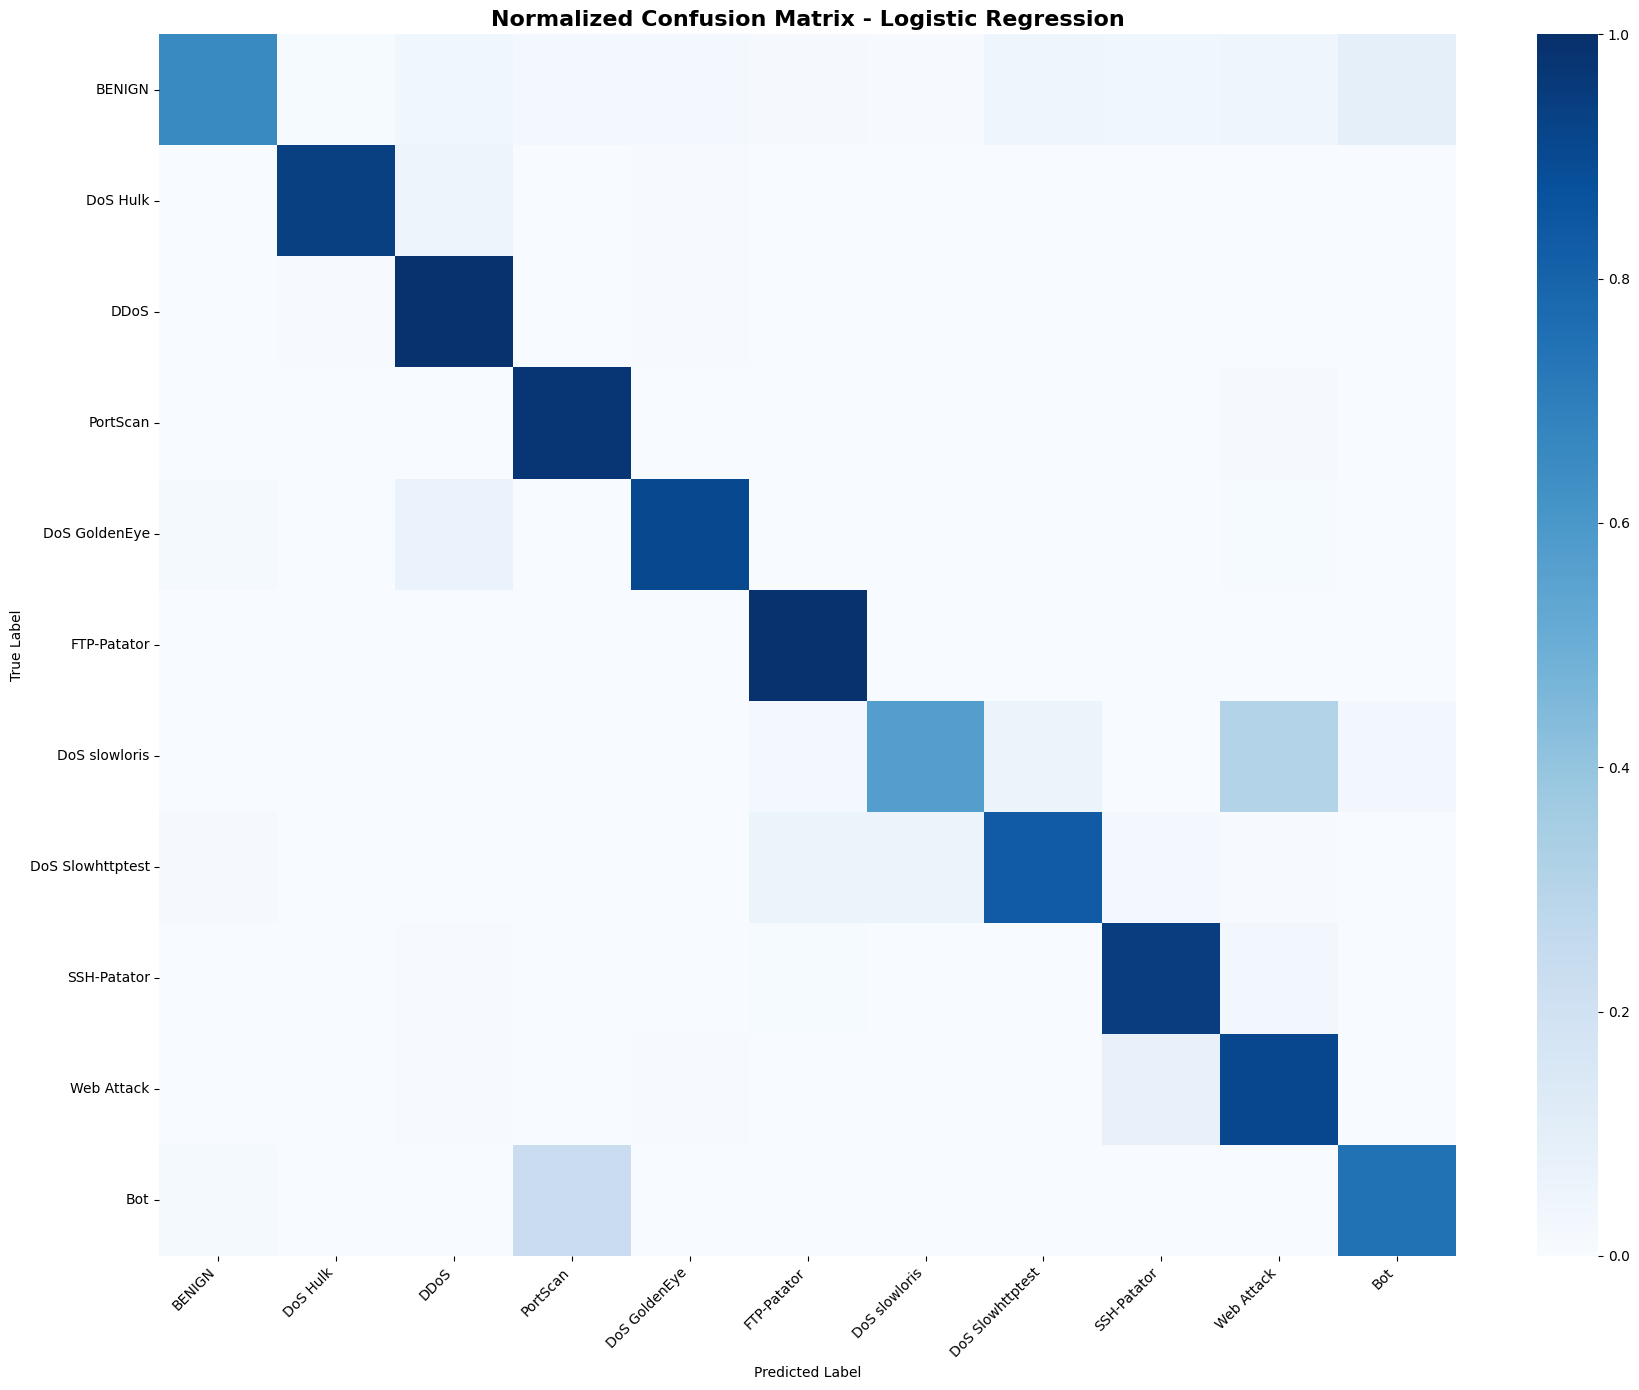

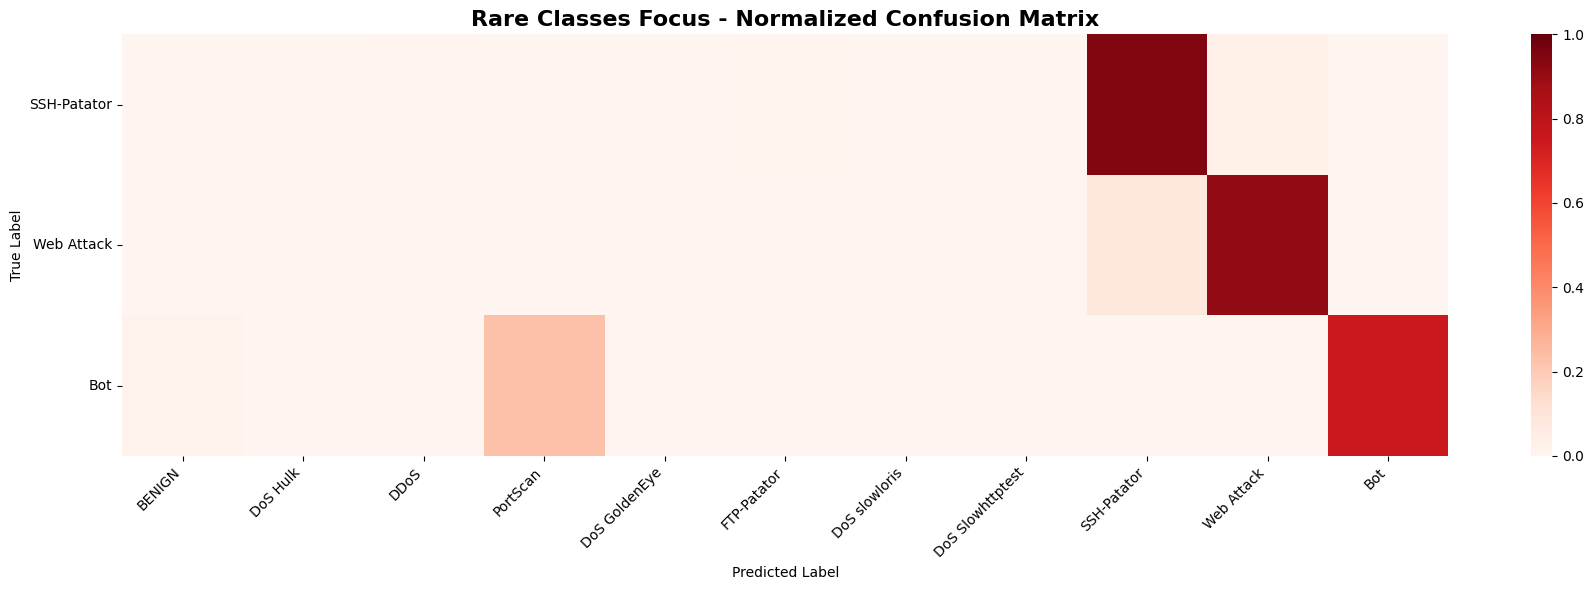


=== Rare class predictions (top 3 predicted labels) ===
SSH-Patator: SSH-Patator=0.95, Web Attack=0.03, FTP-Patator=0.01
Web Attack: Web Attack=0.91, SSH-Patator=0.07, DDoS=0.01
Bot: Bot=0.75, PortScan=0.23, BENIGN=0.02


In [10]:
# =========================================
# Cell 10: Confusion Matrix
# =========================================
true_counts = Counter(y_test)

ordered_labels = [lbl for lbl, _ in sorted(true_counts.items(), key=lambda x: x[1], reverse=True)]
ordered_names = le.inverse_transform(np.array(ordered_labels))

cm = confusion_matrix(y_test, y_pred, labels=ordered_labels)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap='Blues',
    xticklabels=ordered_names,
    yticklabels=ordered_names,
    vmin=0,
    vmax=1
)
plt.title('Normalized Confusion Matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rare_threshold = 1000
rare_labels = [lbl for lbl in ordered_labels if true_counts[lbl] <= rare_threshold]

if len(rare_labels) >= 2:
    rare_names = le.inverse_transform(np.array(rare_labels))
    rare_idx = [ordered_labels.index(lbl) for lbl in rare_labels]
    cm_rare = cm_norm[np.ix_(rare_idx, range(len(ordered_labels)))]

    plt.figure(figsize=(18, max(6, 0.6 * len(rare_labels) + 2)))
    sns.heatmap(
        cm_rare,
        annot=False,
        cmap='Reds',
        xticklabels=ordered_names,
        yticklabels=rare_names,
        vmin=0,
        vmax=1
    )
    plt.title('Rare Classes Focus - Normalized Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\n=== Rare class predictions (top 3 predicted labels) ===")
    for lbl in rare_labels:
        name = le.inverse_transform([lbl])[0]
        row = cm_norm[ordered_labels.index(lbl)]
        top_idx = np.argsort(row)[::-1][:3]
        top_preds = [(ordered_names[i], row[i]) for i in top_idx if row[i] > 0]
        if top_preds:
            print(f"{name}: " + ", ".join([f"{n}={v:.2f}" for n, v in top_preds]))
        else:
            print(f"{name}: no predictions")

In [11]:
# =========================================
# Cell 11: Lưu model + metadata (Đã fix đường dẫn chuẩn xác)
# =========================================
import os
import json
import joblib
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "models"
if not (PROJECT_ROOT / "data").exists():
    MODEL_DIR = Path.cwd() / "models"
os.makedirs(MODEL_DIR, exist_ok=True)

artifact = {
    "model": pipeline,
    "label_encoder": le,
    "features": selected_features,
    "metrics": {
        "accuracy": float(acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "train_time_sec": float(train_time)
    }
}

model_path = MODEL_DIR / "ids_logistic_regression_best.pkl"
metrics_path = MODEL_DIR / "ids_logistic_regression_best_metrics.json"

joblib.dump(artifact, model_path)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(artifact["metrics"], f, ensure_ascii=False, indent=2)

print(f"Đã lưu model tại: {model_path}")
print(f"Đã lưu metrics tại: {metrics_path}")

Đã lưu model tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\models\ids_logistic_regression_best.pkl
Đã lưu metrics tại: d:\hoc\ATBM HTTT\Lab 6\IDS-Logistic-Regression\models\ids_logistic_regression_best_metrics.json


In [12]:
# =========================================
# Cell 12: Hàm dự đoán 1 mẫu mới
# =========================================
def predict_one(sample_dict):
    sample_df = pd.DataFrame([sample_dict])[selected_features]
    pred_id = pipeline.predict(sample_df)[0]
    pred_label = le.inverse_transform([pred_id])[0]
    return pred_label
